<a href="https://colab.research.google.com/github/Adimaster1/RL-jx/blob/main/snakes_ladders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1: The Value of a Ladder
### Snakes and Ladders as a Markov Decision Process

**Reinforcement Learning, Electronics & Robotics Club x Quark Controls, BITS Goa**

This week you turn a board game you already know into a Markov Decision Process and
solve it with the Bellman equations. You will:

- **Level 1 (prediction).** Build the transition matrix of the plain game, solve for
  the expected number of turns from every square with one matrix inverse, and check it
  against a Monte Carlo playout. Then design your own board and race the cohort.
- **Level 2 (control).** Add a choice of die each turn, and use value iteration to find
  the policy that finishes in the fewest turns.
- **Level 3 (concepts).** Evaluate a random (stochastic) policy, see why two different
  reward designs give the same optimal policy, and watch value iteration contract.

Work top to bottom. Wherever you see `# ===== YOUR CODE HERE =====`, that is your part;
the helper module never does the maths for you. Keep the paper derivations (Part A of
the assignment) next to you: the mini board there is the same idea at a size you can
check by hand.

## 0. Setup

In [ ]:
# Get the helper module. On Colab it will ask you to upload sl_playground.py.
try:
    from sl_playground import *
except ModuleNotFoundError:
    try:
        from google.colab import files
        print("Upload sl_playground.py (it is in the assignment bundle).")
        files.upload()
        from sl_playground import *
    except Exception as e:
        raise RuntimeError(
            "Could not import sl_playground.py. Put it next to this notebook."
        ) from e

import numpy as np
import matplotlib.pyplot as plt
set_style()

print("Ready.")
print("Canonical board:", len(CANONICAL_LADDERS), "ladders,",
      len(CANONICAL_SNAKES), "snakes.")
print("States run from", START, "(start, off the board) to", FINISH, "(finish).")

Upload sl_playground.py (it is in the assignment bundle).


Saving sl_playground.py to sl_playground.py
Ready.
Canonical board: 9 ladders, 10 snakes.
States run from 0 (start, off the board) to 100 (finish).


---
# Level 1: Prediction, the Bellman Expectation Equation

With one fair die and no choices, the board is a **Markov reward process (MRP)**: a
Markov chain with a reward on every step. There are no decisions yet, you just roll and
move. This level is about **prediction**: work out the value of every square.

**The model.**
- **States** `0..100`: the square you are resting on. Square `0` is the start (you begin
  off the board), square `100` is the finish. That is 101 states, so every array below
  has length 101 and `P` is `101 x 101`.
- **Transitions**: roll a fair die (faces `1..6`, each with probability `1/6`), move
  forward, **stay put if the move would pass 100**, then **teleport** if you land on a
  ladder or snake.
- **Reward** `-1` per turn until you reach the finish; discount `gamma = 1`.

**Why value is minus the expected turns.** With a reward of `-1` on every turn, the
return from a square is `-(number of turns until you finish)`. So the value, which is
the expected return, is `v(s) = -h(s)`, where `h(s)` is the expected number of turns to
reach 100 from `s`. We compute `h` and negate it.

**The Bellman expectation equation.** You spend one turn, then land somewhere and carry
on. Counting turns, that reads

$$ h(s) = 1 + \sum_{s'} P(s' \mid s)\, h(s'), \qquad h(100) = 0, $$

or in vector form `h = 1 + P h` (a `1` for the turn you spend, then the average over
where you land). This is the same "cost now plus value of the next state" idea as the
notes, written for turns.

**Solving it: the fundamental matrix.** Split the states into the 100 *transient*
squares `0..99` and the absorbing finish `100`. Let `Q` be the transient-to-transient
block of `P` (its top-left `100 x 100` corner). Using `h(100) = 0`, the equation becomes
`h = 1 + Q h`, so

$$ (I - Q)\, h = \mathbf{1} \quad\Longrightarrow\quad h = (I - Q)^{-1}\mathbf{1}. $$

`(I - Q)^{-1}` is the **fundamental matrix** from Week 0. It is invertible here because
the finish is reached with probability 1 from every square, so the series
`I + Q + Q^2 + ...` converges (that series counts the expected visits to each square).
This is an exact solve: no learning, no iteration.

**Why the current square is a Markov state.** Where you go next depends only on the
square you are on and the die you roll, never on the path that brought you there. Even
the ladders and snakes respect this: which teleport fires is decided by the square you
land on, not by your history.

### 1.2 Build the transition matrix `P`

Write `build_P(jump, faces)`. It returns the `101 x 101` matrix where `P[s, s']` is the
probability of going from square `s` to square `s'` in one turn, using a die whose
`faces` are all equally likely. Work out, for each non-terminal square, where a single
turn can take you:

- roll the die (each face equally likely) and move forward by that many squares;
- if the move would take you past square 100, you do not move that turn (the overshoot
  rule);
- if you land on a ladder foot or snake mouth, you are teleported at once to its other
  end.

Square 100 is absorbing: once there, you stay there.

The provided `jump` map sends a landing square to its teleport destination; a square
that is not in `jump` has no ladder or snake. Get the canonical `jump` from
`make_jump()`. (Because landing on a jump square teleports you the same turn, you never
come to rest on one, so no special case is needed for them.)

In [ ]:
def build_P(jump, faces):
    n = FINISH + 1

    P = np.zeros((n, n))
    # ===== YOUR CODE HERE =====
    pb = 1/len(faces)

    for s in range(n):
      if s == FINISH :
        P[s,FINISH] = 1.0
        continue

      for d in faces :
        next = s+d
        if next > FINISH :
          next = s
        elif next in jump:
          next = jump[next]

        P[s, next] += pb

    # row_sums = P.sum(axis=1)

    # for i, s in enumerate(row_sums):
    #   if not np.isclose(s, 1.0):
    #     print(i, s)


    # raise NotImplementedError("Fill in build_P, then delete this line.")
    return P

jump = make_jump()                      # canonical board
fair = list(range(1, 7))                # a fair six-sided die
P = build_P(jump, fair)
assert np.allclose(P.sum(axis=1), 1.0), "every row of P must sum to 1"
print("P built, rows sum to 1.")

P built, rows sum to 1.


### 1.3 Solve for the expected turns with the fundamental matrix

Using the derivation from the top of this level, form the transient block of `P` (the
part among the squares `0..99`) and solve the linear system `(I - Q) h = 1`. Solving the
system directly is more accurate than forming the inverse and multiplying by it. The
value is then `v(s) = -h(s)`.

Then draw the value heatmap with `draw_board(values=...)`.

Expected turns from the start (square 0): 39.225


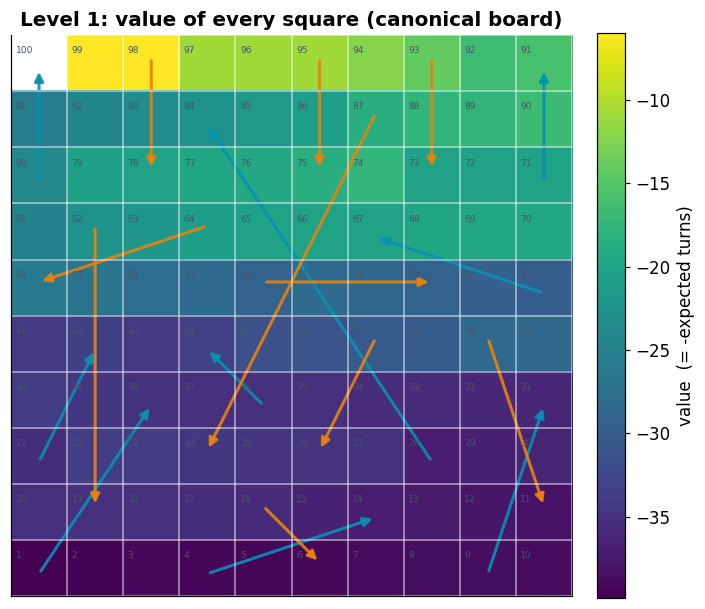

In [ ]:
def expected_turns(P):
    "Return h[0..99]: expected turns to reach square 100 from each square."
    # ===== YOUR CODE HERE =====
    P_transient = P[:100, :100] #need only 100*100 since state 100 is terminal
    I = np.identity(100)
    ones = np.ones(100)
    h =  np.linalg.solve(I-P_transient,ones)
    return h

h = expected_turns(P)
print(f"Expected turns from the start (square 0): {h[0]:.3f}")

# value = -expected turns; draw it as a heatmap over squares 1..99
values = {s: -h[s] for s in range(1, FINISH)}
draw_board(values=values, value_label="value  (= -expected turns)",
           title="Level 1: value of every square (canonical board)")
plt.show()

### 1.4 Reconcile with Monte Carlo

Write `simulate_turns(jump, faces, trials, seed)` that actually plays the game
`trials` times from the start and returns the average number of turns. It should
land near `h[0]` (roughly 39 on the canonical board). This is the Week 0 idea again:
when in doubt, simulate, and the average converges.

> **Heads-up.** A simulation is random, so it will not match the exact value to the
> last digit. A gap of a few hundredths over a few hundred thousand games is exactly
> right; that is the Law of Large Numbers from Week 0. Remember that one turn is one
> roll whether or not it moves you: an overshoot that makes you stay put still costs a
> turn.

In [ ]:
def simulate_turns(jump, faces, trials=200_000, seed=0):
    rng = np.random.default_rng(seed)
    # ===== YOUR CODE HERE ====
    total_turns = 0
    for trial in range(trials) :
      state = START
      turns = 0


      while state!= FINISH:
        roll = rng.integers(1,7)

        next = state+ roll
        if next > FINISH :
          next = state
        elif next in jump:
          next = jump[next]

        state = next

        turns +=1

      total_turns += turns

    return total_turns / trials
    # while current_state != FINISH :
    #   if s = CANNONICAL_SNAKES jump = make_jump()

    # raise NotImplementedError("Fill in simulate_turns, then delete this line.")

mc = simulate_turns(jump, fair, 200_000, seed=1)
report("expected turns from start", mc, h[0])

expected turns from start       computed =  39.2341   reference =  39.2251   |gap| = 0.0090


In [ ]:
import time

start = time.time()
mc = simulate_turns(jump,fair,trials= 1000,seed=1)
print(time.time()-start)

0.12082266807556152


### 1.5 Read the board (written answer)

Look at your heatmap and answer in a sentence or two (edit this cell):

- Which ordinary square has the **fewest** expected turns remaining, and which has the
  **most**?


---


  ANS: Fewest : 2 | Most : 99



---


- You will also find that standing on the **start (square 0)** is better than standing
  on **square 2**. Explain why, using the board.



---

ANS : sq(1) has a ladder which improves its state-value


---



### 1.6 Board-Designer Challenge: the Speedrun (leaderboard)

You are the game designer now. Keep the fair die and every rule the same, but **move
the snakes and ladders wherever you like**, as long as the board stays legal: the same
**9 ladders and 10 snakes**, ladders climbing, snakes sliding, no square used twice.

**Goal: minimise the expected turns from the start**, scored by your own solver. Post
your board's heatmap and your number to the Agent Zoo. Lowest wins.

Edit `my_ladders` and `my_snakes` below. `board_is_legal` checks the rules;
`build_P` + `expected_turns` give your score. There is no single right answer, we
want to see how differently people think.

Legal board: 9 ladders, 10 snakes.
YOUR SCORE (expected turns from start): 12.324
(canonical board was 39.225; lower is faster)


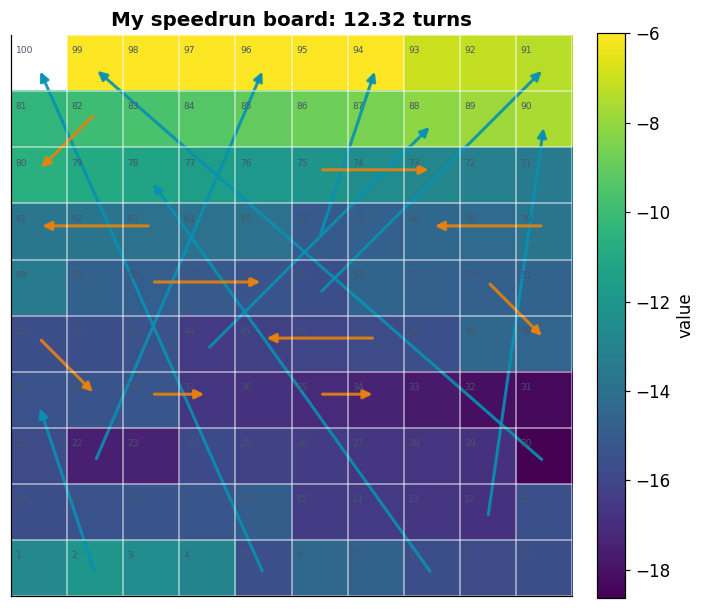

In [ ]:
# Design your board. (These are just a starting point, change them!)
my_ladders = {2: 40, 5: 100, 8: 78, 12: 90, 22: 96, 30: 99, 44: 88, 55: 91, 66: 94}
my_snakes  = {35: 34, 38: 37, 41: 39, 47: 45, 52: 50, 58: 56, 63: 61, 70: 68,
              75: 73, 82: 80}

assert board_is_legal(my_ladders, my_snakes, n_ladders=9, n_snakes=10)

my_jump = make_jump(my_ladders, my_snakes)
my_h = expected_turns(build_P(my_jump, fair))
print(f"YOUR SCORE (expected turns from start): {my_h[0]:.3f}")
print(f"(canonical board was {h[0]:.3f}; lower is faster)")

draw_board(my_ladders, my_snakes, values={s: -my_h[s] for s in range(1, FINISH)},
           value_label="value", title=f"My speedrun board: {my_h[0]:.2f} turns")
plt.show()

---
# Level 2: Control, the Bellman Optimality Equation

Now you get a **choice** each turn: roll the **safe die** `{1,2,3}` or the **risky die**
`{1,2,3,4,5,6}`. That makes this a Markov **decision** process with actions
`A = {safe, risky}`. The goal is still to reach 100 in the fewest turns, but now you
decide which die to roll on each square.

**Background you need.**
- An **action** picks which die you roll, and each action `a` has its own transition
  matrix `P_a`. A **policy** `pi` says which action to take on each square.
- The **action-value** `q(s, a)` is the expected turns if you take action `a` now and
  then continue optimally: `q(s, a) = 1 + sum_s' P_a(s' | s) h*(s')`. The **state-value**
  is the best action's value, `h*(s) = min_a q(s, a)`. The **advantage**
  `q(s, risky) - q(s, safe)` measures how much one die beats the other on that square
  (negative means risky is better).
- The **Bellman optimality equation** writes that self-consistently:
  `h*(s) = min_a [ 1 + sum_s' P_a(s' | s) h*(s') ]`, with `h*(100) = 0`. Because the
  finish is reachable under either die, this has a unique solution, and **value
  iteration** (sweeping the right-hand side until it stops changing) converges to it,
  even though `gamma = 1` here.

We will (a) build one transition matrix per action, (b) evaluate a fixed policy with the
matrix solve, and (c) find the optimal policy by value iteration.

### 2.1 One transition matrix per action

Reuse `build_P` with the two face sets to get `P_safe` and `P_risky`.

In [ ]:
safe_faces  = [1, 2, 3]
risky_faces = [1, 2, 3, 4, 5, 6]
P_safe  = build_P(jump, safe_faces)
P_risky = build_P(jump, risky_faces)
print("Built P_safe and P_risky.")

Built P_safe and P_risky.


### 2.2 Fixing a policy collapses the MDP into an MRP

If you commit to one die everywhere, there is no choice left, so the MDP becomes an
MRP and your Level 1 solver applies directly. Evaluate **always-risky** and check it
against the Level 1 value, then explain in one line why the two must match.

In [ ]:
h_always_risky = expected_turns(P_risky)
h_always_safe  = expected_turns(P_safe)
report("always-risky, turns from start", h_always_risky[0], h[0])
print(f"always-safe, turns from start: {h_always_safe[0]:.3f}")

always-risky, turns from start  computed =  39.2251   reference =  39.2251   |gap| = 0.0000
always-safe, turns from start: 65.901


*Why does always-risky match Level 1 exactly?*


---
ANS : risky approach is the same transition probabilities since die has same faces with equal prob


---



### 2.3 Value iteration for the optimal policy

Solve the Bellman **optimality** equation

$$ h_*(s) = \min_{a \in \{\text{safe},\,\text{risky}\}}
   \Big( 1 + \sum_{s'} P(s' \mid s, a)\, h_*(s') \Big), \qquad h_*(100) = 0, $$

by sweeping until `h_*` stops changing. Return `h_star`, the policy `pi` (0 = safe,
1 = risky) as the action that attains the minimum, and the action-value table `Q`
(shape `2 x 101`) so you can read the advantage between the two dice.

Optimal expected turns from start: 27.017  (vs 39 with one die)


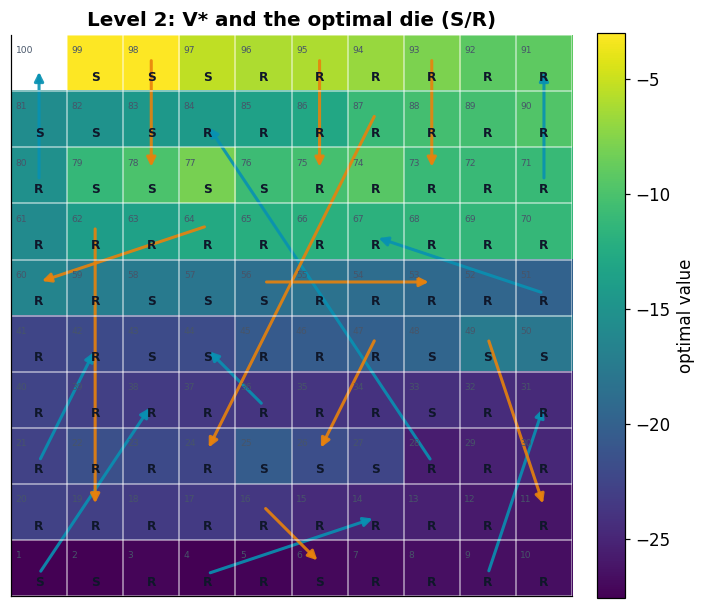

In [ ]:
def value_iteration(P_list, tol=1e-10, itmax=100_000):
    "Minimise expected turns. Returns (h_star, pi, Q)."
    h = np.zeros(FINISH + 1)

    # ===== YOUR CODE HERE =====
     #.copy() creates new copy otherwise same memory pointing
    Q = np.zeros(2*FINISH).reshape(2,FINISH)
    pi = np.ones(100)

    for iteration in range(itmax) :
      h_new = h.copy()

      for s in range(FINISH) :
        q_safe = 1 + np.dot(P_list[0][s], h)
        q_risky = 1 + np.dot(P_list[1][s], h)
        h_new[s] = min(q_safe, q_risky)
        pi[s] = np.argmin([q_safe, q_risky])
        Q[0, s] = q_safe
        Q[1, s] = q_risky

      delta = np.max(np.abs(h_new - h))
      h = h_new
      if delta <tol :
        break
    return h_new,pi,Q
    # raise NotImplementedError("Fill in value_iteration, then delete this line.")

h_star, pi, Q = value_iteration([P_safe, P_risky])
print(f"Optimal expected turns from start: {h_star[0]:.3f}  (vs 39 with one die)")

advantage = Q[1] - Q[0]     # risky minus safe; negative means risky is better
choice = {s: ("R" if pi[s] == 1 else "S") for s in range(1, FINISH)}
draw_board(values={s: -h_star[s] for s in range(1, FINISH)}, policy=choice,
           value_label="optimal value", title="Level 2: V* and the optimal die (S/R)")
plt.show()

### 2.4 Reconcile: simulate the policies

Write `simulate_policy(jump, pi, faces_by_action, trials, seed)` that plays `trials`
games, rolling the die that `pi` picks for the current square, and returns the average
turns. Compare the optimal policy to always-safe and always-risky. The optimal average
should match `h_star[0]` (near 27).

In [ ]:
def simulate_policy(jump, pi, faces_by_action, trials=200_000, seed=0):
    rng = np.random.default_rng(seed)
    # ===== YOUR CODE HERE =====
    q_star = np.zeros((2,FINISH))
    pi = np.ones(FINISH + 1, dtype=int)

    total_turns = 0
    for trial in range(trials) :
      state = START
      turns = 0
      action = 0
      faces = faces_by_action[action]



      while state!= FINISH:
        action = pi[state]
        faces = faces_by_action[action]
        roll = rng.choice(faces)
        # pi[state] = np.argmin([q_star[0],q_star[1] ])

        next = state+ roll
        if next > FINISH :
          next = state
        elif next in jump:
          next = jump[next]

        state = next

        turns +=1

      total_turns += turns

    return total_turns / trials

faces_by_action = [safe_faces, risky_faces]     # index 0 = safe, 1 = risky
mc_star = simulate_policy(jump, pi, faces_by_action, 200_000, seed=2)
report("optimal policy, turns from start", mc_star, h_star[0])

# always-safe and always-risky as constant policies, for comparison
pi_safe  = np.zeros(FINISH + 1, dtype=int)
pi_risky = np.ones(FINISH + 1, dtype=int)
print(f"always-safe : {simulate_policy(jump, pi_safe, faces_by_action, 50_000, 3):.2f}")
print(f"always-risky: {simulate_policy(jump, pi_risky, faces_by_action, 50_000, 4):.2f}")

optimal policy, turns from start  computed =  39.2408   reference =  27.0167   |gap| = 12.2242
always-safe : 39.36
always-risky: 39.19


In [ ]:
import time

start = time.time()
mc = simulate_policy(jump,pi,faces_by_action,trials= 1000,seed=1)
print(time.time()-start)

0.6173052787780762


### 2.5 The endgame (written answer)

Print the choice and the two action-values for the last squares, then explain the
switch (edit the markdown cell after).

In [ ]:
for s in range(94, FINISH):
    print(f"square {s}:  Q(safe)={Q[0,s]:5.2f}  Q(risky)={Q[1,s]:5.2f}  "
          f"-> {'safe' if pi[s]==0 else 'risky'}")

square 94:  Q(safe)= 8.21  Q(risky)= 6.76  -> risky
square 95:  Q(safe)= 8.10  Q(risky)= 6.06  -> risky
square 96:  Q(safe)= 7.08  Q(risky)= 6.06  -> risky
square 97:  Q(safe)= 5.31  Q(risky)= 5.81  -> safe
square 98:  Q(safe)= 3.00  Q(risky)= 3.50  -> safe
square 99:  Q(safe)= 3.00  Q(risky)= 3.50  -> safe


*Read your policy board: near which squares does the optimal die change, and
why does the best choice flip there?*


---
Ans : 97th sqaure


---




---
# Level 3: Stochastic Policies, Reward Design, and Contraction

Three shorter tasks that round out the theory.

### 3.1 Evaluate a stochastic policy

A policy need not be deterministic. Suppose on every square you flip a coin and roll
the safe die with probability 1/2, the risky die with probability 1/2. The induced
transition is the policy-weighted average
`P_pi = 0.5 * P_safe + 0.5 * P_risky`. Evaluate it with the matrix solve, and compare
to the optimal and to always-risky.

In [ ]:
P_mix = 0.5 * P_safe + 0.5 * P_risky
h_mix = expected_turns(P_mix)
print(f"coin-flip policy: {h_mix[0]:.3f} turns")
print(f"optimal         : {h_star[0]:.3f} turns")
print(f"always-risky    : {h[0]:.3f} turns")

coin-flip policy: 48.432 turns
optimal         : 27.017 turns
always-risky    : 39.225 turns


### 3.2 Reward design: a different reward, the same optimal policy

Instead of `-1` per turn, use reward `0` everywhere except `+100` on the step that
reaches square 100, and discount `gamma = 0.95`. Now we **maximise** value. Write the
discounted value iteration for this reward and read off its optimal policy.

**Background.** This is still the Bellman optimality equation, now with a `max` over
actions and a discounted future:

$$ v_*(s) = \max_a \Big( r(s, a) + \gamma \sum_{s'} P_a(s' \mid s)\, v_*(s') \Big), $$

where the reward `r(s, a)` is `0` unless the step reaches the finish, in which case it
is `+100`. Compare the resulting policy, and its value numbers, with Level 2.

In [ ]:
def value_iteration_discounted(P_list, gamma=0.95, terminal_reward=100.0,
                               tol=1e-10, itmax=100_000):
    "Maximise discounted value. Returns (v, pi, gaps) where gaps[k] = sup-norm change."
    v = np.zeros(FINISH + 1)
    gaps = []
    # ===== YOUR CODE HERE =====
    pi = np.zeros(FINISH +1 , dtype = int)
    # action_index = 0
    # pi = action_index
    r = np.zeros(FINISH+1)
    r[FINISH] = terminal_reward
    for iteration in range(itmax) :
       v_new = v.copy()
       Q = np.zeros((len(P_list),FINISH +1))
       v_new[FINISH] = terminal_reward

       for s in range(FINISH):
          for a in range(len(P_list)):
            Q[a,s] = r[s]+gamma*np.dot(P_list[a][s], v)

          pi[s]= np.argmax(Q[:,s])
          v_new[s]= np.max(Q[:,s])
       gap = np.max(np.abs(v_new-v))
       gaps.append(gap)

       v = v_new

       if gap<tol :
        break

      # for s in range(FINISH +1) :
      #   if s == 100 :
      #     r[s] = terminal_reward
      #   v_safe = r[s] + gamma * np.dot(h, (P_list[0][s]))
      #   v_risky = r[s]+ gamma * np.dot(h , (P_list[1][s]))
      #   if v_risky>v_safe:
      #     v_new[s] = v_risky
      #     action_index = 1
      #   v_new[s] = v_safe

      # v = v_new
      # pi = action_index

    return v,pi,gaps
    # raise NotImplementedError("Fill in value_iteration_discounted, then delete this.")

v_disc, pi_disc, gaps = value_iteration_discounted([P_safe, P_risky], gamma=0.95)
same = np.array_equal(pi[:FINISH], pi_disc[:FINISH])
print("Same optimal policy as Level 2?", same)
print(f"But different values: v(start) = {v_disc[0]:.3f} (a discounted reward, "
      f"not a turn count).")

Same optimal policy as Level 2? True
But different values: v(start) = 31.092 (a discounted reward, not a turn count).


In [ ]:
import time

start = time.time()
mc = value_iteration_discounted([P_safe,P_risky], gamma=0.95,itmax = 1000)
print(time.time()-start)

0.23203587532043457


*In one line: why do two different reward designs give the same optimal
policy?* (edit)

### 3.3 Watch the contraction

**Background.** The Bellman optimality operator `T` (one full sweep of value iteration)
is a `gamma`-contraction in the sup-norm: `||T v - T w||_inf <= gamma * ||v - w||_inf`,
which the notes prove. So the gap between successive sweeps,
`||v_{k+1} - v_k||_inf`, shrinks by at least a factor `gamma` each time. On a log
`y`-axis that is a straight line with slope `log(gamma)`. That contraction is exactly
*why* value iteration is guaranteed to converge.

Plot the recorded sup-norm change per sweep (`gaps`) on a log `y`-axis and compare it to
a line falling at rate `gamma`.

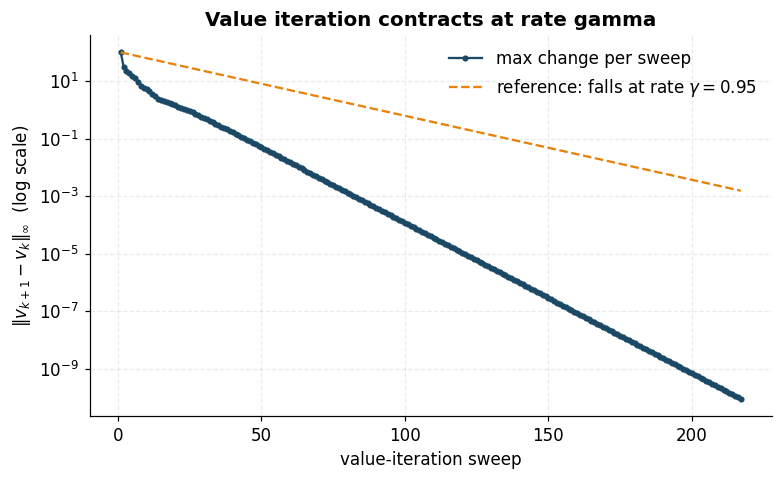

In [ ]:
fig, ax = plt.subplots()
ax.semilogy(range(1, len(gaps) + 1), gaps, marker="o", ms=3,
            color=PALETTE["blue"], label="max change per sweep")
# a reference line falling at rate gamma = 0.95
ref = gaps[0] * 0.95 ** np.arange(len(gaps))
ax.semilogy(range(1, len(gaps) + 1), ref, ls="--", color=PALETTE["orange"],
            label=r"reference: falls at rate $\gamma=0.95$")
ax.set_xlabel("value-iteration sweep")
ax.set_ylabel(r"$\|v_{k+1}-v_k\|_\infty$  (log scale)")
ax.set_title("Value iteration contracts at rate gamma")
ax.legend()
plt.show()

---
## You are done

Post to the **Agent Zoo**:
1. your **Level 1 expected-turns heatmap** and your **board-designer score**, and
2. your **Level 2 optimal-policy board** (the S/R map).

Then hand in this notebook (all blanks filled, all plots showing) with your Part A
paper derivations. Next week we stop solving these by matrix inverse and learn the
**dynamic programming** that scales: policy evaluation, policy iteration, and value
iteration on a gridworld.